In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "Muscle data2.csv"  # Change this to your actual file path
df = pd.read_csv(file_path)

# Display first few rows
df.head()


,0,1,2,3,4,5,6,7,label
0,-1212.50,-665.50,-180.75,199.25,555.75,1454.50,612.50,236.00,5
1,1380.00,-522.25,-931.00,-125.75,652.50,1536.25,660.50,727.75,5
2,1672.25,-429.75,-1738.75,-288.00,732.25,1678.75,452.75,830.25,5
3,1624.25,-185.25,-2116.75,317.75,861.00,1593.25,158.25,1025.50,5
4,1287.00,-215.00,-1539.25,667.50,930.25,1252.75,-1144.75,903.00,5


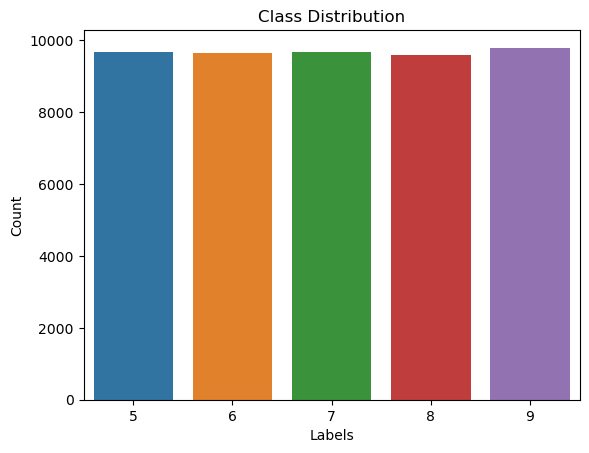

In [2]:
# Count the occurrences of each label
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()


In [3]:
# Show basic statistics for each feature
df.describe()


,0,1,2,3,4,5,6,7,label
count,48357.000000,48357.000000,48357.000000,48357.000000,48357.000000,48357.000000,48357.000000,48357.000000,48357.000000
mean,-46.645274,9.434120,-27.238724,-0.033475,14.687682,27.722512,32.919433,16.050360,7.004508
std,755.678889,507.086209,708.937466,551.274262,1060.318990,777.293180,750.919237,846.314361,1.416471
min,-3357.500000,-2739.000000,-3809.750000,-2871.000000,-3540.000000,-3208.500000,-3511.250000,-3720.250000,5.000000
25%,-491.750000,-230.500000,-389.500000,-291.000000,-692.250000,-472.750000,-448.000000,-521.750000,6.000000
50%,-32.750000,15.250000,-23.500000,-15.750000,14.250000,35.250000,39.000000,19.750000,7.000000
75%,387.750000,250.250000,335.500000,285.250000,729.250000,520.250000,513.000000,548.000000,8.000000
max,3209.000000,2864.250000,3159.250000,2981.250000,3723.500000,3134.000000,3182.250000,3190.000000,9.000000


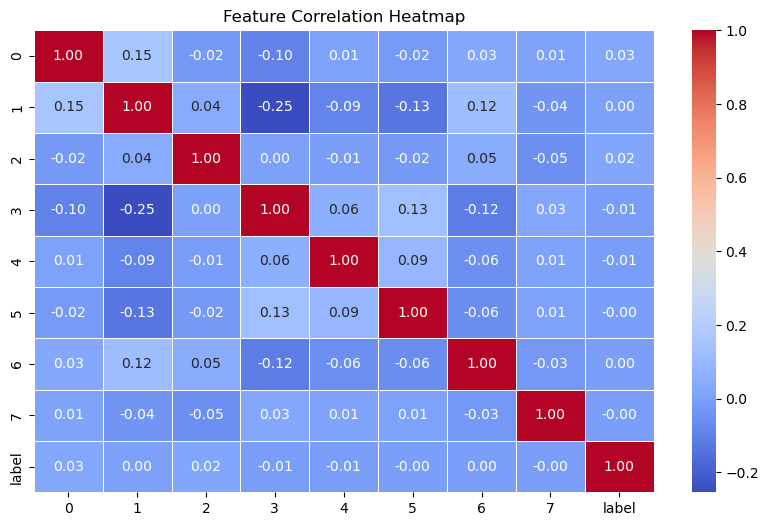

In [4]:
# Compute correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


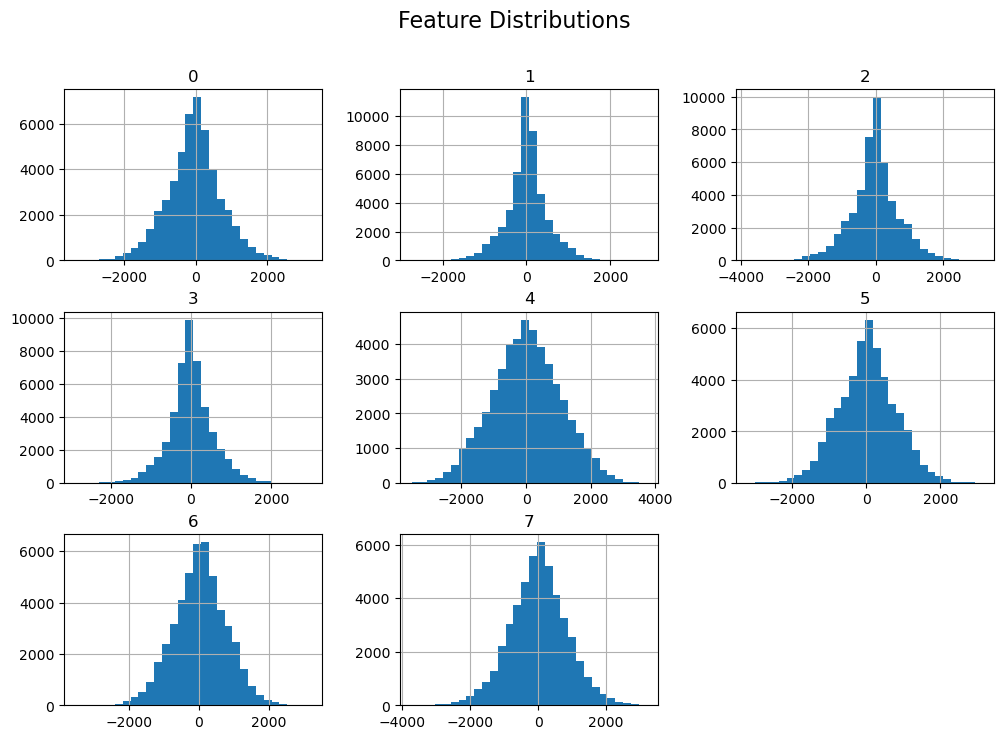

In [5]:
# Plot distribution for each feature
df.iloc[:, :-1].hist(figsize=(12, 8), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


In [6]:
# Check for missing values
print(df.isnull().sum())

# If there are missing values, fill them (e.g., with mean)
df.fillna(df.mean(), inplace=True)


0        0
1        0
2        0
3        0
4        0
5        0
6        0
7        0
label    0
dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df.iloc[:, :-1] = scaler.fit_transform(df.iloc[:, :-1])  # Scale only features, not labels


In [12]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df.iloc[:, :-1]  # Features
y = df['label']      # Labels

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Shift labels to start from 0 (Fix for XGBoost)
y_train = y_train - 5
y_test = y_test - 5

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 38685, Testing samples: 9672


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", C=1.0),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.2264
Random Forest: Accuracy = 0.6223
SVM: Accuracy = 0.5337


C:\Users\Asus\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [10:48:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost: Accuracy = 0.5549
